In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
# Local project data files are expected in the data/ directory

import os
for dirname, _, filenames in os.walk('data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data\Dataset - Updated.csv
data\Maternal_Health_Risk_Assessment Original Dataset.csv


## IMPORTING DATASETS

### With dataset 1

In [5]:
df1 = pd.read_csv('data/Dataset - Updated.csv')
df1 = df1[df1['Age']<100]
X = df1.copy()
y1 = X.pop('Risk Level')

In [6]:
missing_features = X.columns[X.isnull().any()].tolist()
missing_features

['Systolic BP',
 'Diastolic',
 'BS',
 'BMI',
 'Previous Complications',
 'Preexisting Diabetes',
 'Heart Rate']

In [7]:
X.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0


In [8]:
new_index = [f + '_missing' for f in missing_features]
X[new_index] = X[missing_features].isnull().astype(int)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant', fill_value=-999)
X[missing_features] = imputer.fit_transform(X[missing_features])

In [9]:
X['MAP'] = ((2 * X['Diastolic']) + X['Systolic BP']) / 3

In [10]:
df1 = pd.concat([pd.DataFrame(X), pd.Series(y1, name='target')], axis=1)
df1 = df1.dropna(subset=['target'])

X = df1.drop('target', axis=1)


In [11]:
y1 = df1['target']

In [12]:
X

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Systolic BP_missing,Diastolic_missing,BS_missing,BMI_missing,Previous Complications_missing,Preexisting Diabetes_missing,Heart Rate_missing,MAP
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,0,0,0,0,0,0,0,70.000000
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,83.333333
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,0,0,0,0,0,0,0,83.333333
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,80.000000
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,70.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,0,0,0,0,0,0,0,110.000000
1201,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,0,0,0,0,0,0,0,96.666667
1202,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,0,0,0,0,0,0,0,123.333333
1203,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,0,0,0,0,0,0,0,110.000000


In [13]:
set(type(val) for val in y1)

{str}

In [14]:
df1

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Systolic BP_missing,Diastolic_missing,BS_missing,BMI_missing,Previous Complications_missing,Preexisting Diabetes_missing,Heart Rate_missing,MAP,target
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,0,0,0,0,0,0,0,70.000000,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,83.333333,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,0,0,0,0,0,0,0,83.333333,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,80.000000,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,70.000000,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,0,0,0,0,0,0,0,110.000000,High
1201,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,0,0,0,0,0,0,0,96.666667,High
1202,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,0,0,0,0,0,0,0,123.333333,High
1203,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,0,0,0,0,0,0,0,110.000000,High


In [15]:
discrete_features = X.dtypes == int

## Some basic Feature Engineering

In [16]:
from sklearn.feature_selection import mutual_info_classif
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [17]:
mi_scores = make_mi_scores(X, y1, discrete_features)

In [18]:
mi_scores

BMI                               0.445109
Heart Rate                        0.335647
BS                                0.323185
Preexisting Diabetes              0.262320
Mental Health                     0.214130
Previous Complications            0.175170
MAP                               0.126708
Gestational Diabetes              0.120466
Diastolic                         0.096785
Systolic BP                       0.087040
Age                               0.060658
Body Temp                         0.025998
Systolic BP_missing               0.001721
Diastolic_missing                 0.000860
BS_missing                        0.000774
Preexisting Diabetes_missing      0.000774
Previous Complications_missing    0.000774
Heart Rate_missing                0.000774
BMI_missing                       0.000247
Name: MI Scores, dtype: float64

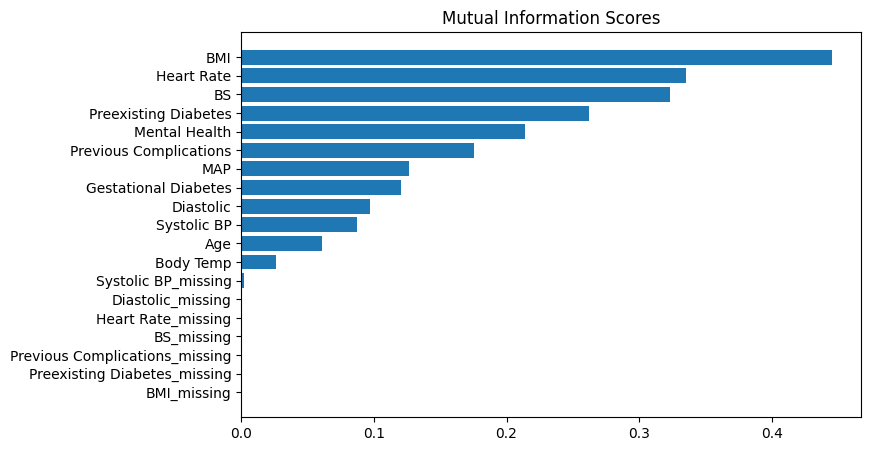

In [19]:
import matplotlib.pyplot as plt
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

In [20]:
df1.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Systolic BP_missing,Diastolic_missing,BS_missing,BMI_missing,Previous Complications_missing,Preexisting Diabetes_missing,Heart Rate_missing,MAP,target
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,0,0,0,0,0,0,0,70.000000,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,83.333333,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,0,0,0,0,0,0,0,83.333333,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,80.000000,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,0,0,0,0,0,0,0,70.000000,Low


C:\Users\Akansha Srivastava\AppData\Local\Temp\ipykernel_17384\2530268998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='BMI', data=df1, palette='Set2')


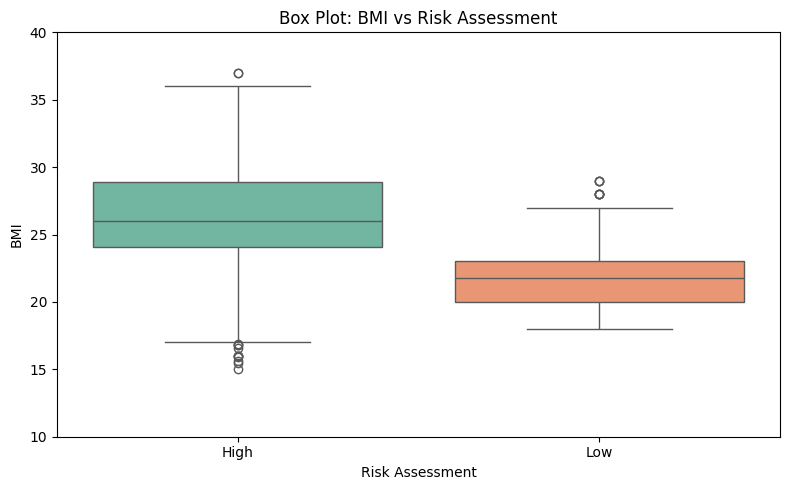

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='BMI', data=df1, palette='Set2')

# Set the y-axis limit to exclude negative values (e.g., starting from 0)
plt.ylim(10, df1['BMI'].max() + 3)  # Adjust 5 or any value to give some space

# Add labels and title
plt.title('Box Plot: BMI vs Risk Assessment')
plt.xlabel('Risk Assessment')
plt.ylabel('BMI')

# Show plot
plt.tight_layout()
plt.show()

BMI can be a good feature

C:\Users\Akansha Srivastava\AppData\Local\Temp\ipykernel_17384\631697734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='Heart Rate', data=df1, palette='Set2')


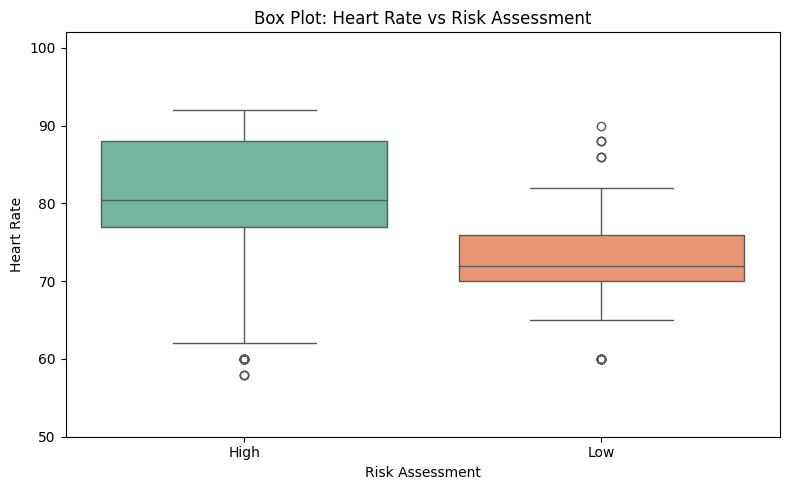

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='Heart Rate', data=df1, palette='Set2')

# Set the y-axis limit to exclude negative values (e.g., starting from 0)
plt.ylim(50, df1['Heart Rate'].max() + 10)  # Adjust 5 or any value to give some space

# Add labels and title
plt.title('Box Plot: Heart Rate vs Risk Assessment')
plt.xlabel('Risk Assessment')
plt.ylabel('Heart Rate')

# Show plot
plt.tight_layout()
plt.show()

Heart Rate can be a good feature

C:\Users\Akansha Srivastava\AppData\Local\Temp\ipykernel_17384\583481981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='BS', data=df1, palette='Set2')


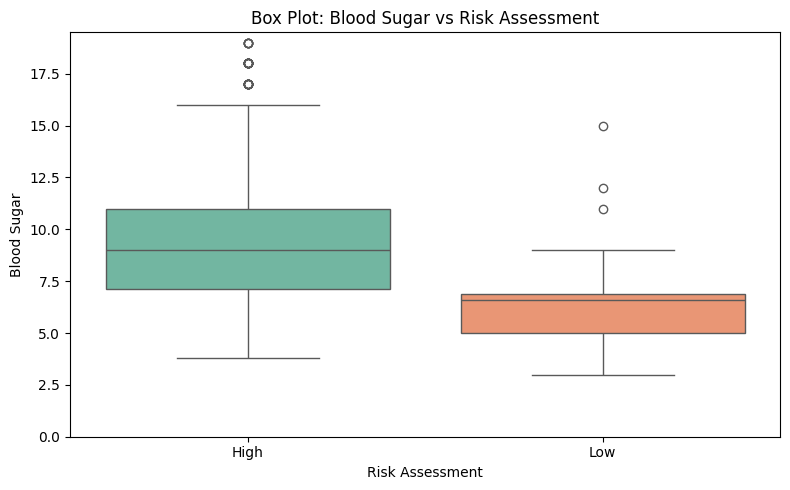

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='BS', data=df1, palette='Set2')

# Set the y-axis limit to exclude negative values (e.g., starting from 0)
plt.ylim(0, df1['BS'].max() + 0.5)  # Adjust 5 or any value to give some space

# Add labels and title
plt.title('Box Plot: Blood Sugar vs Risk Assessment')
plt.xlabel('Risk Assessment')
plt.ylabel('Blood Sugar')

# Show plot
plt.tight_layout()
plt.show()

Blood Sugar Level can be a good factor

C:\Users\Akansha Srivastava\AppData\Local\Temp\ipykernel_17384\2760924955.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='MAP', data=df1, palette='Set2')


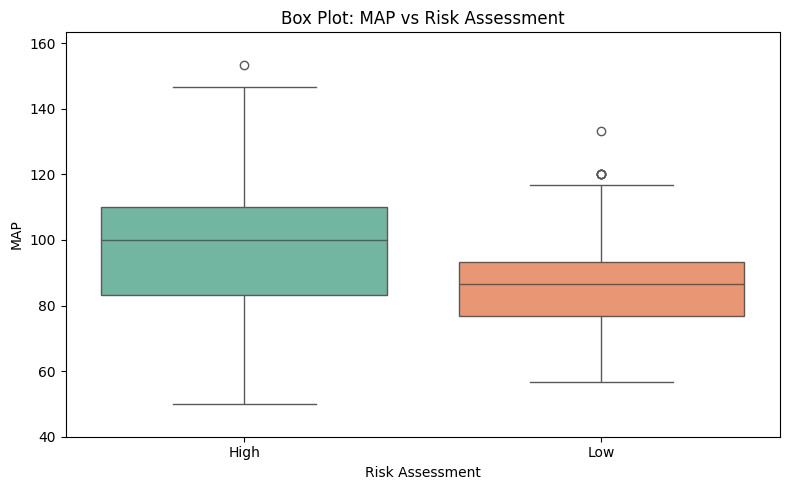

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='MAP', data=df1, palette='Set2')

# Set the y-axis limit to exclude negative values (e.g., starting from 0)
plt.ylim(40, df1['MAP'].max() + 10)  # Adjust 5 or any value to give some space

# Add labels and title
plt.title('Box Plot: MAP vs Risk Assessment')
plt.xlabel('Risk Assessment')
plt.ylabel('MAP')

# Show plot
plt.tight_layout()
plt.show()

MAP is a bad indicator

In [25]:
low_risk_sbp = df1[df1['target'] == 'Low']['Systolic BP']
print(low_risk_sbp.describe())

count    713.000000
mean     106.152875
std       84.382642
min     -999.000000
25%      100.000000
50%      120.000000
75%      120.000000
max      160.000000
Name: Systolic BP, dtype: float64


C:\Users\Akansha Srivastava\AppData\Local\Temp\ipykernel_17384\1805621374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='Age', data=df1, palette='Set2')


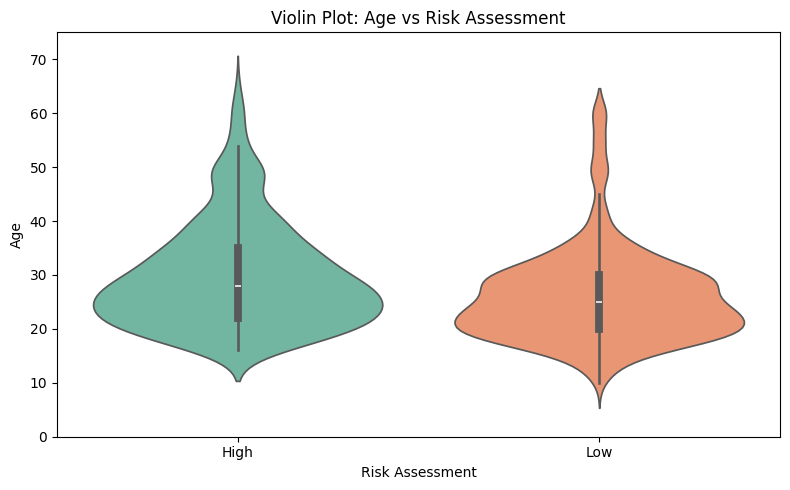

In [26]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='target', y='Age', data=df1, palette='Set2')

# Set the y-axis limit to exclude negative BMI values
plt.ylim(0, df1['Age'].max() + 10)  # Add a margin above the max value

# Add labels and title
plt.title('Violin Plot: Age vs Risk Assessment')
plt.xlabel('Risk Assessment')
plt.ylabel('Age')

# Show the plot
plt.tight_layout()
plt.show()

Age is a bad indicator

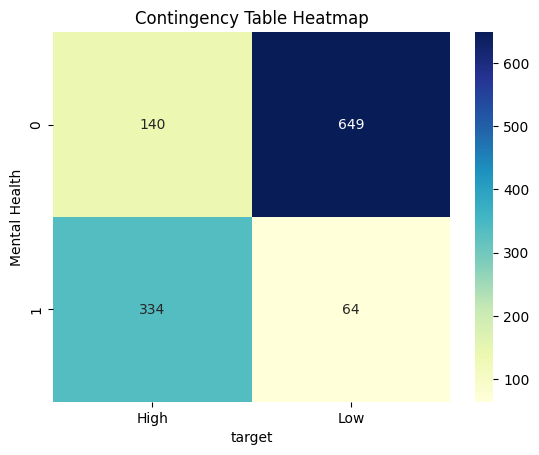

In [27]:
ct = pd.crosstab(df1['Mental Health'], df1['target'])

# Heatmap
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt='d')
plt.title('Contingency Table Heatmap')
plt.xlabel('target')
plt.ylabel('Mental Health')
plt.show()

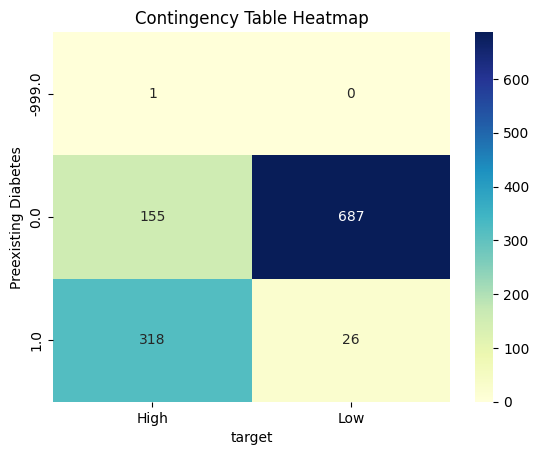

In [28]:
ct = pd.crosstab(df1['Preexisting Diabetes'], df1['target'])

# Heatmap
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt='d')
plt.title('Contingency Table Heatmap')
plt.xlabel('target')
plt.ylabel('Preexisting Diabetes')
plt.show()

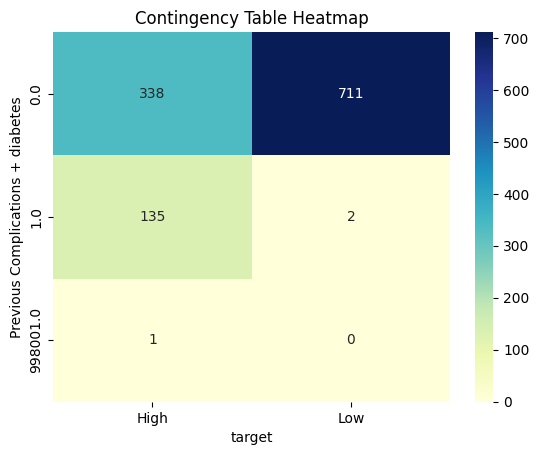

In [29]:
ct = pd.crosstab(df1['Previous Complications']*df1['Preexisting Diabetes'], df1['target'])

# Heatmap
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt='d')
plt.title('Contingency Table Heatmap')
plt.xlabel('target')
plt.ylabel('Previous Complications + diabetes')
plt.show()

Diabetes * Previous Complications is an execellent indicator

In [30]:
df1['Target'] = [1 if f == 'High' else 0 for f in df1['target'] ]

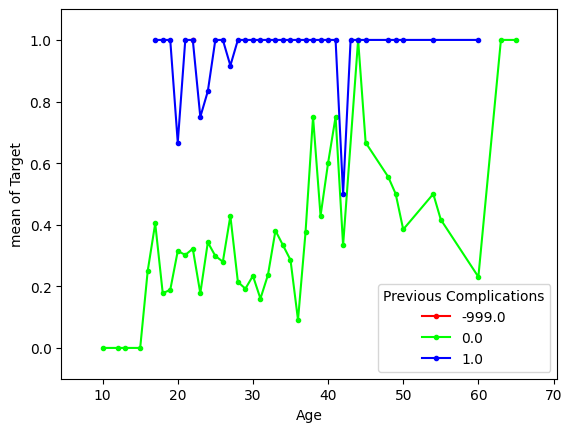

In [31]:
import statsmodels.api as sm
from statsmodels.graphics.factorplots import interaction_plot

interaction_plot(df1['Age'], df1['Previous Complications'], df1['Target'])
plt.show()

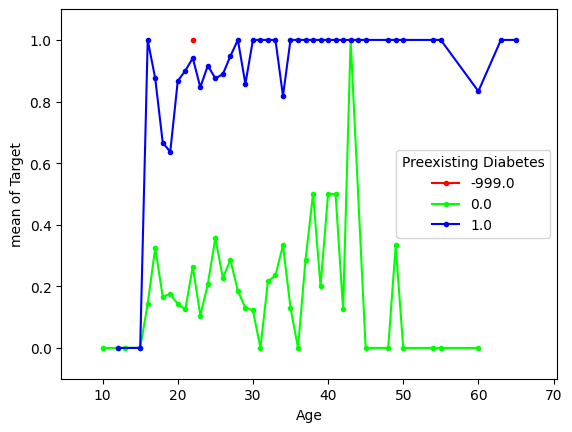

In [32]:
interaction_plot(df1['Age'], df1['Preexisting Diabetes'], df1['Target'])
plt.show()

## Using Model

In [33]:
y1 = [1 if f=='High' else 0 for f in y1]

In [34]:
y1

[1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y1, random_state=1)

In [36]:
X_test,X_valid, y_test, y_valid = train_test_split(X_test,y_test,random_state=1)

In [38]:
X_train = X_train.drop(columns=['MAP'], errors='ignore')
X_test = X_test.drop(columns=['MAP'], errors='ignore')
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    missing=-999.0,
    early_stopping_rounds=10,
    eval_metric='logloss'
 )
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(
    X_train,
    y_train,
    eval_set=eval_set,
    verbose=True
 )

[0]	validation_0-logloss:0.58894	validation_1-logloss:0.59466
[1]	validation_0-logloss:0.51917	validation_1-logloss:0.52802
[2]	validation_0-logloss:0.46130	validation_1-logloss:0.47306
[3]	validation_0-logloss:0.41213	validation_1-logloss:0.42792
[4]	validation_0-logloss:0.37015	validation_1-logloss:0.38823
[5]	validation_0-logloss:0.33361	validation_1-logloss:0.35378
[6]	validation_0-logloss:0.30185	validation_1-logloss:0.32484
[7]	validation_0-logloss:0.27288	validation_1-logloss:0.29628
[8]	validation_0-logloss:0.24744	validation_1-logloss:0.27049
[9]	validation_0-logloss:0.22437	validation_1-logloss:0.24762
[10]	validation_0-logloss:0.20460	validation_1-logloss:0.22818
[11]	validation_0-logloss:0.18633	validation_1-logloss:0.21110
[12]	validation_0-logloss:0.17009	validation_1-logloss:0.19563
[13]	validation_0-logloss:0.15560	validation_1-logloss:0.18176
[14]	validation_0-logloss:0.14352	validation_1-logloss:0.16976
[15]	validation_0-logloss:0.13192	validation_1-logloss:0.15813
[1

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,'logloss'


In [39]:
X_valid.pop('MAP')

994      73.333333
1029     90.000000
516     106.666667
395      93.333333
973     110.666667
           ...    
662      73.333333
49       93.333333
560     100.000000
19       83.333333
1004    106.666667
Name: MAP, Length: 75, dtype: float64

In [40]:
predictions = model.predict(X_valid)
predictions

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1])

In [41]:
y_valid

[1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1]

In [42]:
c=0
for i in range(len(predictions)):
    if y_valid[i] == predictions[i]:
        c+=1
print(c/len(predictions))

1.0


In [43]:
print(df1['target'].value_counts(normalize=True))

target
Low     0.600674
High    0.399326
Name: proportion, dtype: float64


In [44]:
X_valid

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Systolic BP_missing,Diastolic_missing,BS_missing,BMI_missing,Previous Complications_missing,Preexisting Diabetes_missing,Heart Rate_missing
994,25,90.0,65.0,8.0,100,26.0,1.0,1.0,0,1,62.0,0,0,0,0,0,0,0
1029,22,120.0,75.0,6.0,98,23.0,1.0,0.0,1,1,90.0,0,0,0,0,0,0,0
516,49,140.0,90.0,15.0,98,27.0,0.0,1.0,0,0,90.0,0,0,0,0,0,0,0
395,26,120.0,80.0,4.8,98,23.0,0.0,0.0,0,1,74.0,0,0,0,0,0,0,0
973,49,140.0,96.0,19.0,98,29.5,1.0,1.0,0,1,86.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,16,90.0,65.0,6.9,98,24.0,0.0,0.0,0,0,76.0,0,0,0,0,0,0,0
49,18,120.0,80.0,6.0,98,19.4,0.0,0.0,0,1,76.0,0,0,0,0,0,0,0
560,19,120.0,90.0,5.0,102,17.0,0.0,0.0,0,1,90.0,0,0,0,0,0,0,0
19,21,110.0,70.0,6.6,98,20.0,0.0,1.0,0,1,74.0,0,0,0,0,0,0,0


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, predictions, target_names=['Low', 'High']))

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        45
        High       1.00      1.00      1.00        30

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [46]:
from sklearn.metrics import r2_score
r2_score(y_valid, predictions)

1.0